# Black Friday Dataset EDA and Feature Engineering
### Cleaning and preparing the data for model training

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Problem Statement
A retail company "ABC Private Limited" wants to understand the customer purchase behaviour (Specially, purchase amount) against various products of different categories. They have shared purchase sumarry of various customers for selected high volume products from last months.
the dataset also contains customer demographics (age , gender , marital status, city_type ,stay_in_current_city) , product details (product-id, and product category) and total purchase_amount from last month.


Now, they want to build a model to predict the purchase amount of customer against various products which will help them to create personalized offer for customer against different products.

In [4]:
# importing dataset
df_train = pd.read_csv("train.csv")
df_train.shape

(550068, 12)

In [6]:
df_train.isnull().sum()

User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            173638
Product_Category_3            383247
Purchase                           0
dtype: int64

In [8]:
df_test = pd.read_csv("test.csv")
df_test.shape

(233599, 11)

In [10]:
df_test.isnull().sum()

User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2             72344
Product_Category_3            162562
dtype: int64

In [12]:
df_train.head(3)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422


In [14]:
df_test.head(3)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3
0,1000004,P00128942,M,46-50,7,B,2,1,1,11.0,NaN
1,1000009,P00113442,M,26-35,17,C,0,0,3,5.0,NaN
2,1000010,P00288442,F,36-45,1,B,4+,1,5,14.0,NaN


In [16]:
df = pd.concat([df_train,df_test],ignore_index=True)

In [18]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370.0
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200.0
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422.0
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057.0
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969.0


In [20]:
df.shape

(783667, 12)

In [22]:
df.isnull().sum()

User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            245982
Product_Category_3            545809
Purchase                      233599
dtype: int64

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 783667 entries, 0 to 783666
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     783667 non-null  int64  
 1   Product_ID                  783667 non-null  object 
 2   Gender                      783667 non-null  object 
 3   Age                         783667 non-null  object 
 4   Occupation                  783667 non-null  int64  
 5   City_Category               783667 non-null  object 
 6   Stay_In_Current_City_Years  783667 non-null  object 
 7   Marital_Status              783667 non-null  int64  
 8   Product_Category_1          783667 non-null  int64  
 9   Product_Category_2          537685 non-null  float64
 10  Product_Category_3          237858 non-null  float64
 11  Purchase                    550068 non-null  float64
dtypes: float64(3), int64(4), object(5)
memory usage: 71.7+ MB


In [26]:
df.drop(["User_ID"],axis=1,inplace=True)

In [28]:
df.columns

Index(['Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1',
       'Product_Category_2', 'Product_Category_3', 'Purchase'],
      dtype='object')

In [30]:
en_data = df[["Gender"]]
en_data

,Gender
0,F
1,F
2,F
3,F
4,M
...,...
783662,F
783663,F
783664,F
783665,F


In [32]:
pd.get_dummies(en_data,drop_first=1)

,Gender_M
0,False
1,False
2,False
3,False
4,True
...,...
783662,False
783663,False
783664,False
783665,False


In [34]:
from sklearn.preprocessing import OneHotEncoder

In [36]:
ohe = OneHotEncoder(drop="first")
arr = ohe.fit_transform(en_data).toarray()
arr

array([[0.],
       [0.],
       [0.],
       ...,
       [0.],
       [0.],
       [0.]])

In [38]:
df["Gender_M"] = pd.DataFrame(arr,columns=["Gender_M"])

In [40]:
df.drop(["Gender"],axis=1,inplace=True)

In [42]:
## Handle Categorical feature Age
df["Age"].unique()

array(['0-17', '55+', '26-35', '46-50', '51-55', '36-45', '18-25'],
      dtype=object)

In [44]:
df["Age"] = df["Age"].map({'0-17':17,'18-25':21.5,'26-35':31.5,'36-45':40.5,'46-50':48,'51-55':53,'55+':58})


In [46]:
df.head()

,Product_ID,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,Gender_M
0,P00069042,17.0,10,A,2,0,3,NaN,NaN,8370.0,0.0
1,P00248942,17.0,10,A,2,0,1,6.0,14.0,15200.0,0.0
2,P00087842,17.0,10,A,2,0,12,NaN,NaN,1422.0,0.0
3,P00085442,17.0,10,A,2,0,12,14.0,NaN,1057.0,0.0
4,P00285442,58.0,16,C,4+,0,8,NaN,NaN,7969.0,1.0


In [48]:
df['City_Category'].unique()

array(['A', 'C', 'B'], dtype=object)

In [50]:
df_city = pd.get_dummies(df['City_Category'])

In [52]:
from sklearn.preprocessing import OneHotEncoder

In [54]:
ohe = OneHotEncoder()
arr = ohe.fit_transform(df[['City_Category']]).toarray()
arr

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       ...,
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.]])

In [56]:
df1 = pd.DataFrame(arr,columns=['A_en','B_en','C_en'])

In [58]:
df = pd.concat([df,df1],axis=1)

In [60]:
df['Stay_In_Current_City_Years'].unique()

array(['2', '4+', '3', '1', '0'], dtype=object)

In [62]:
df.drop("City_Category",axis=1,inplace=True)

In [64]:
# Missing Values
df.isnull().sum()

Product_ID                         0
Age                                0
Occupation                         0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            245982
Product_Category_3            545809
Purchase                      233599
Gender_M                           0
A_en                               0
B_en                               0
C_en                               0
dtype: int64

In [66]:
## replacing missing values
df['Product_Category_1'].unique()

array([ 3,  1, 12,  8,  5,  4,  2,  6, 14, 11, 13, 15,  7, 16, 18, 10, 17,
        9, 20, 19], dtype=int64)

In [68]:
df['Product_Category_2'].unique()

array([nan,  6., 14.,  2.,  8., 15., 16., 11.,  5.,  3.,  4., 12.,  9.,
       10., 17., 13.,  7., 18.])

In [70]:
df['Product_Category_3'].unique()

array([nan, 14., 17.,  5.,  4., 16., 15.,  8.,  9., 13.,  6., 12.,  3.,
       18., 11., 10.])

In [72]:
df['Product_Category_2'].mode()[0]

8.0

In [74]:
## replacing missing values with mod()
df['Product_Category_2'] = df['Product_Category_2'].fillna(df['Product_Category_2'].mode()[0])

In [76]:
df['Product_Category_3'].mode()[0]

16.0

In [78]:
df['Product_Category_3'] = df['Product_Category_3'].fillna(df['Product_Category_3'].mode()[0])

In [80]:
df.isnull().sum()

Product_ID                         0
Age                                0
Occupation                         0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2                 0
Product_Category_3                 0
Purchase                      233599
Gender_M                           0
A_en                               0
B_en                               0
C_en                               0
dtype: int64

In [82]:
df['Product_Category_2'].value_counts()

Product_Category_2
8.0     337299
14.0     78834
2.0      70498
16.0     61687
15.0     54114
5.0      37165
4.0      36705
6.0      23575
11.0     20230
17.0     19104
13.0     15054
9.0       8177
12.0      7801
10.0      4420
3.0       4123
18.0      4027
7.0        854
Name: count, dtype: int64

In [84]:
df['Product_Category_3'].value_counts()

Product_Category_3
16.0    592278
15.0     39968
14.0     26283
17.0     23818
5.0      23799
8.0      17861
9.0      16532
12.0     13115
13.0      7849
6.0       6888
18.0      6621
4.0       2691
11.0      2585
10.0      2501
3.0        878
Name: count, dtype: int64

In [86]:
df['Purchase'].unique()

array([ 8370., 15200.,  1422., ...,   123.,   613.,    nan])

In [88]:
df['Purchase'].value_counts()

Purchase
7011.0     191
7193.0     188
6855.0     187
6891.0     184
7012.0     183
          ... 
23491.0      1
18345.0      1
3372.0       1
855.0        1
21489.0      1
Name: count, Length: 18105, dtype: int64

In [90]:
df['Purchase'].mode()

0    7011.0
Name: Purchase, dtype: float64

In [92]:
df['Stay_In_Current_City_Years'].unique()

array(['2', '4+', '3', '1', '0'], dtype=object)

In [94]:
df['Stay_In_Current_City_Years'] = df['Stay_In_Current_City_Years'].str.replace('+','')

In [96]:
df['Stay_In_Current_City_Years'] = df['Stay_In_Current_City_Years'].astype('int64')

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 783667 entries, 0 to 783666
Data columns (total 13 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Product_ID                  783667 non-null  object 
 1   Age                         783667 non-null  float64
 2   Occupation                  783667 non-null  int64  
 3   Stay_In_Current_City_Years  783667 non-null  int64  
 4   Marital_Status              783667 non-null  int64  
 5   Product_Category_1          783667 non-null  int64  
 6   Product_Category_2          783667 non-null  float64
 7   Product_Category_3          783667 non-null  float64
 8   Purchase                    550068 non-null  float64
 9   Gender_M                    783667 non-null  float64
 10  A_en                        783667 non-null  float64
 11  B_en                        783667 non-null  float64
 12  C_en                        783667 non-null  float64
dtypes: float64(8),

In [100]:
df['Gender_M'] = df['Gender_M'].astype(int)
df['A_en'] = df['A_en'].astype(int)
df['B_en'] = df['B_en'].astype(int)
df['C_en'] = df['C_en'].astype(int)
df['Product_Category_2'] = df['Product_Category_2'].astype(int)
df['Product_Category_3'] = df['Product_Category_3'].astype(int)
df['Occupation'] = df['Occupation'].astype(int)
df['Stay_In_Current_City_Years'] = df['Stay_In_Current_City_Years'].astype(int)
df['Marital_Status'] = df['Marital_Status'].astype(int)
df['Product_Category_1'] = df['Product_Category_1'].astype(int)

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 783667 entries, 0 to 783666
Data columns (total 13 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Product_ID                  783667 non-null  object 
 1   Age                         783667 non-null  float64
 2   Occupation                  783667 non-null  int32  
 3   Stay_In_Current_City_Years  783667 non-null  int32  
 4   Marital_Status              783667 non-null  int32  
 5   Product_Category_1          783667 non-null  int32  
 6   Product_Category_2          783667 non-null  int32  
 7   Product_Category_3          783667 non-null  int32  
 8   Purchase                    550068 non-null  float64
 9   Gender_M                    783667 non-null  int32  
 10  A_en                        783667 non-null  int32  
 11  B_en                        783667 non-null  int32  
 12  C_en                        783667 non-null  int32  
dtypes: float64(2),

In [ ]:
sns.pairplot(df)
plt.show()

In [ ]:
### Visualization Age Vs Purchase

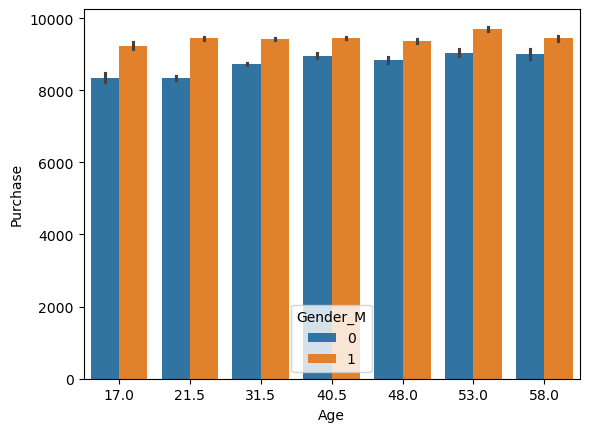

In [109]:
sns.barplot(x = 'Age',y = 'Purchase',hue='Gender_M',data=df)
plt.show()

### Observation
purchasing of men are high than women

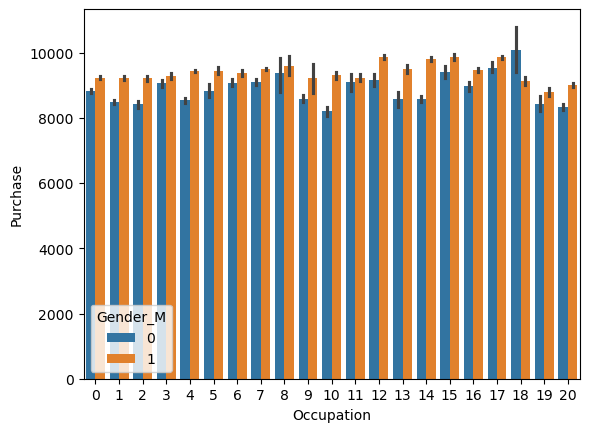

In [112]:
### Visualization of purchase with occupation
sns.barplot(x='Occupation',y='Purchase',hue='Gender_M',data=df)
plt.show()

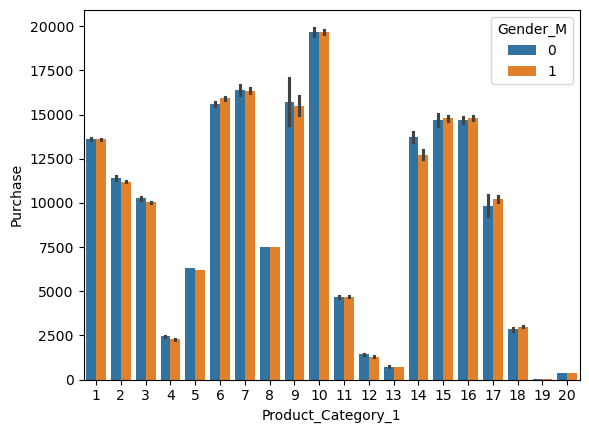

In [114]:
### Visualization of purchase with Product_category_1
sns.barplot(x='Product_Category_1',y='Purchase',hue='Gender_M',data=df)
plt.show()

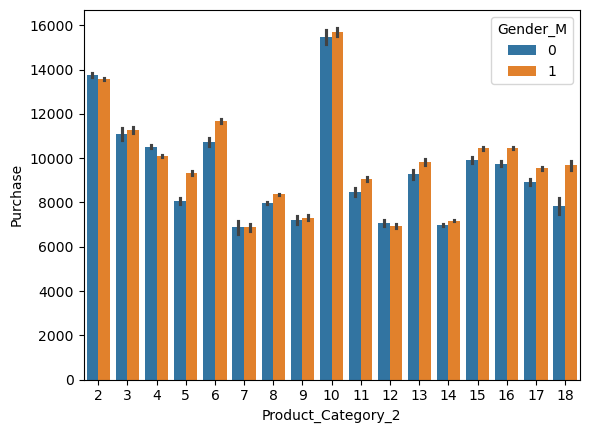

In [116]:
### Visualization of purchase with Product_category_2
sns.barplot(x='Product_Category_2',y='Purchase',hue='Gender_M',data=df)
plt.show()

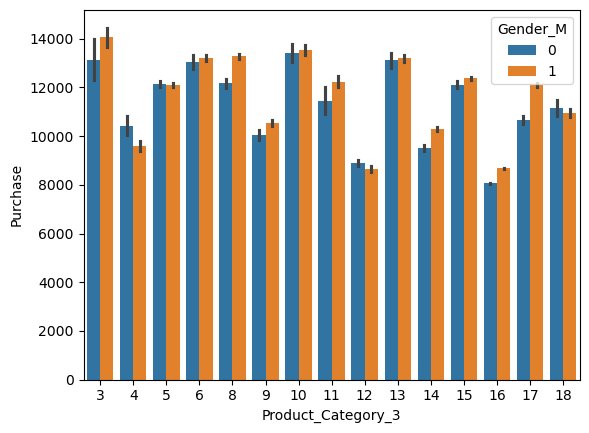

In [117]:
### Visualization of purchase with Product_category_3
sns.barplot(x='Product_Category_3',y='Purchase',hue='Gender_M',data=df)
plt.show()

In [120]:
## Feature Scalling
df_test = df[df['Purchase'].isnull()]

In [122]:
df_train = df[df['Purchase'].isnull()]